In [24]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [25]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline

In [26]:
def plot_invert(df, g, sigma, n_sample):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Objective
    ax1 = axes[0]

    for s in range(n_sample):
        sample_df = df[df['sample'] == s]
        ax1.plot(sample_df['iter'].values, sample_df['objective'].values, 
                marker='o', markersize=2, linewidth=1, alpha=0.7, label=f'Sample {s}')
        
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Objective', fontsize=12)
    ax1.set_title('Objective vs Iteration', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Plot MSE
    ax2 = axes[1]

    for s in range(n_sample):
        sample_df = df[df['sample'] == s]
        ax2.plot(sample_df['iter'].values, sample_df['mse'].values, 
                marker='o', markersize=2, linewidth=1, alpha=0.7, label=f'Sample {s}')
        
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('MSE (log scale)', fontsize=12)
    ax2.set_title('MSE vs Iteration', fontsize=14)
    ax2.set_yscale('log')
    ax2.legend()

    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2.grid(True, which='both', alpha=0.3)
    ax2.grid(True, which='major', alpha=0.5)

    fig.suptitle(f'Invert for gaussian {g} at sigma {sigma}', fontsize=14)
    plt.grid()
    plt.show()

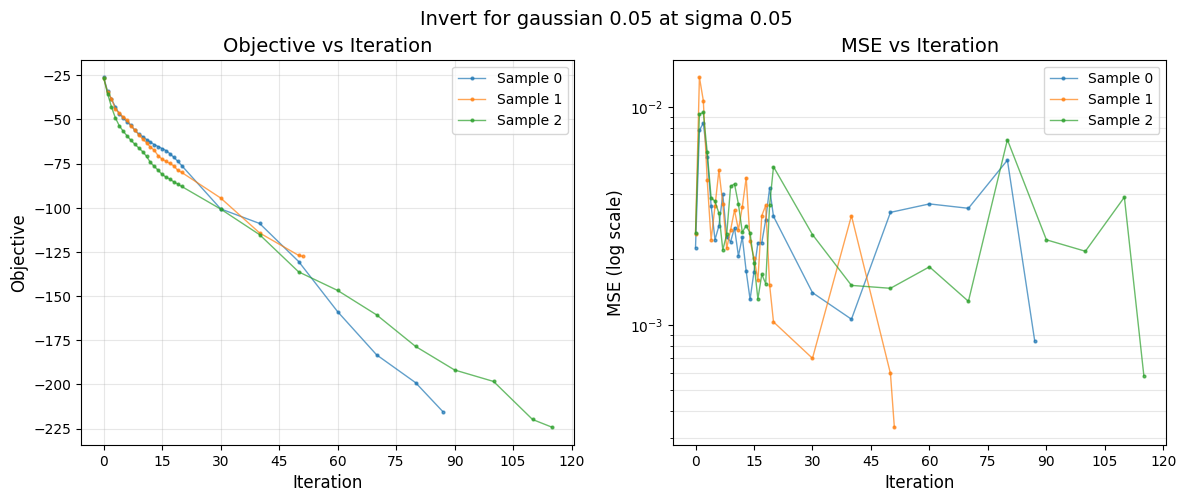

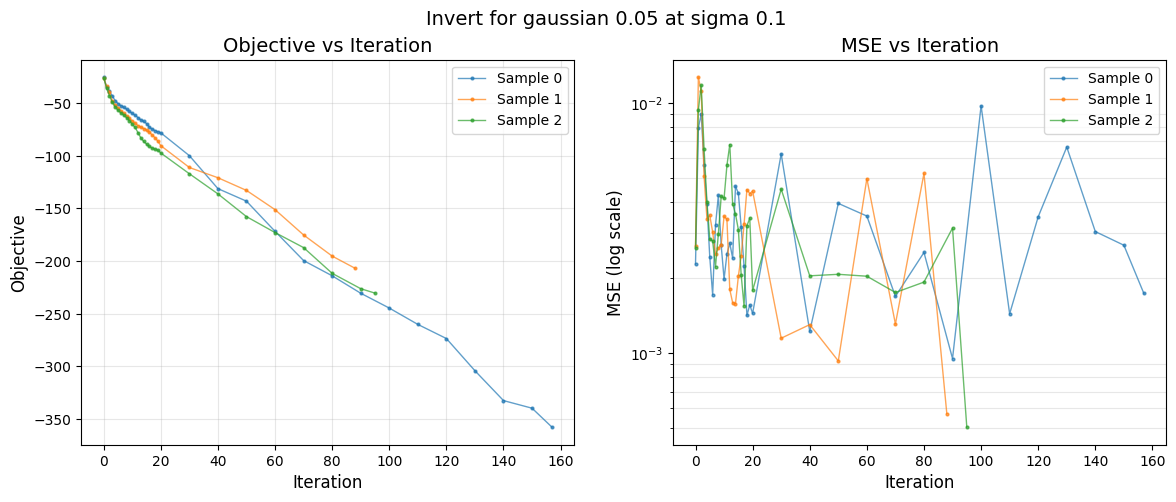

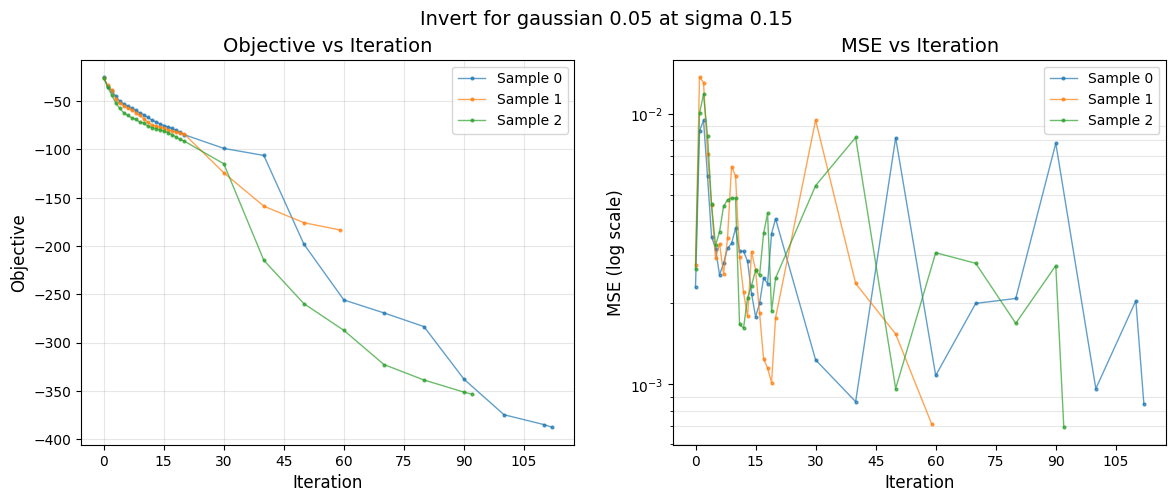

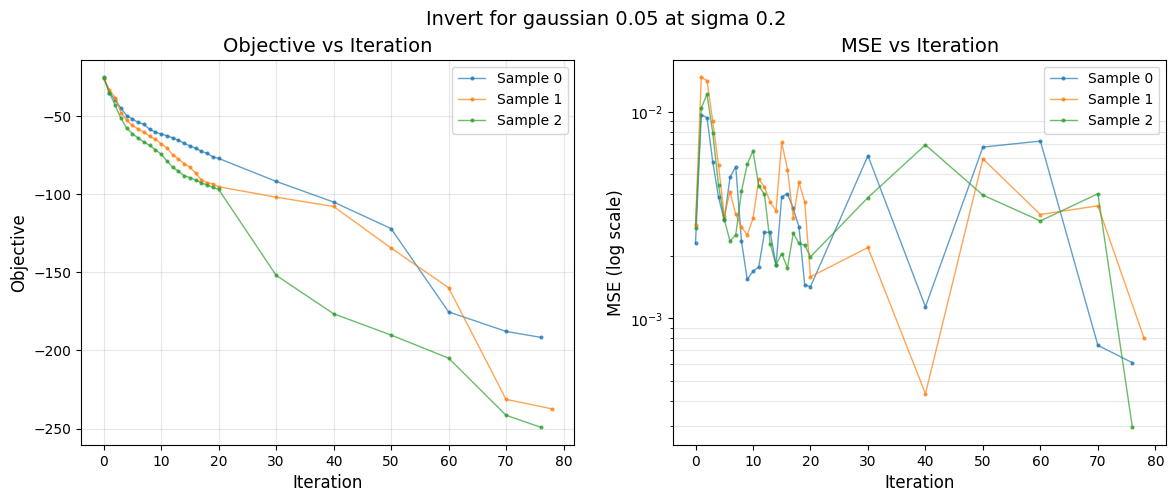

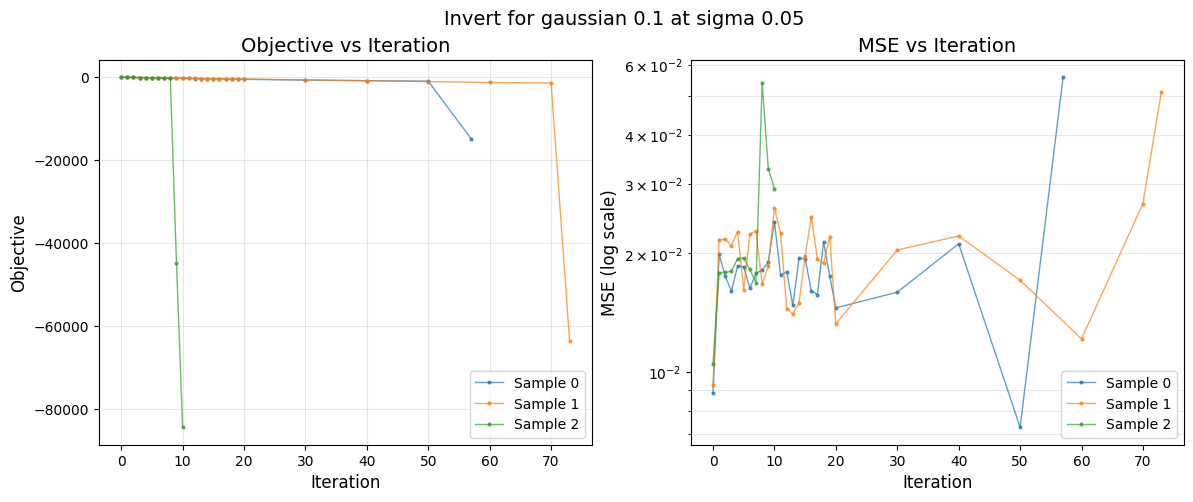

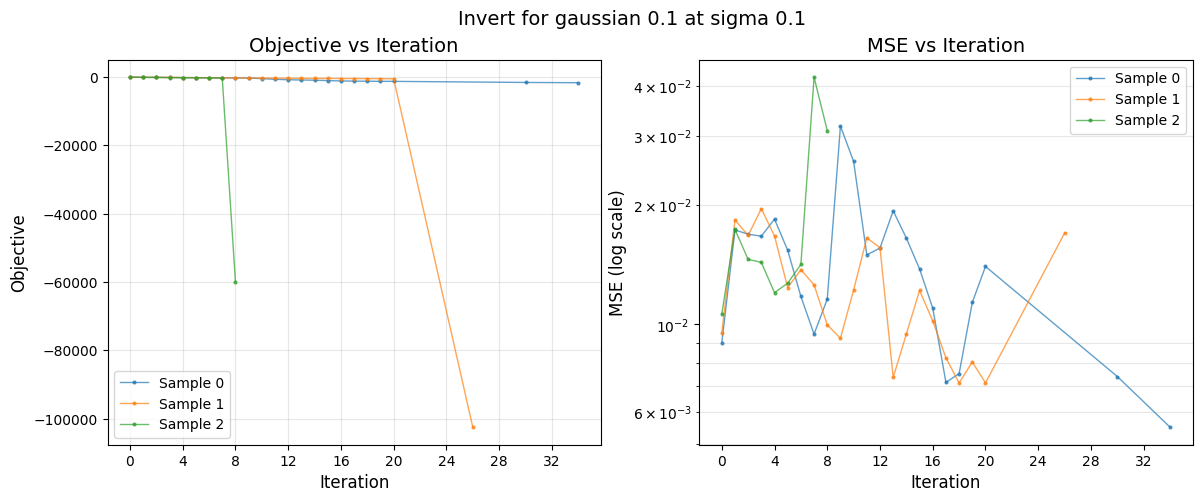

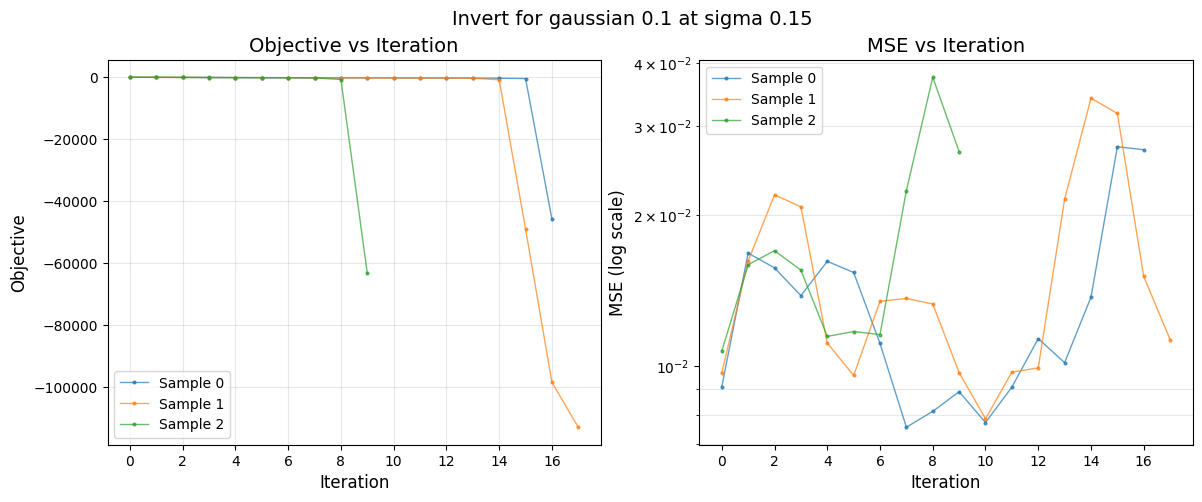

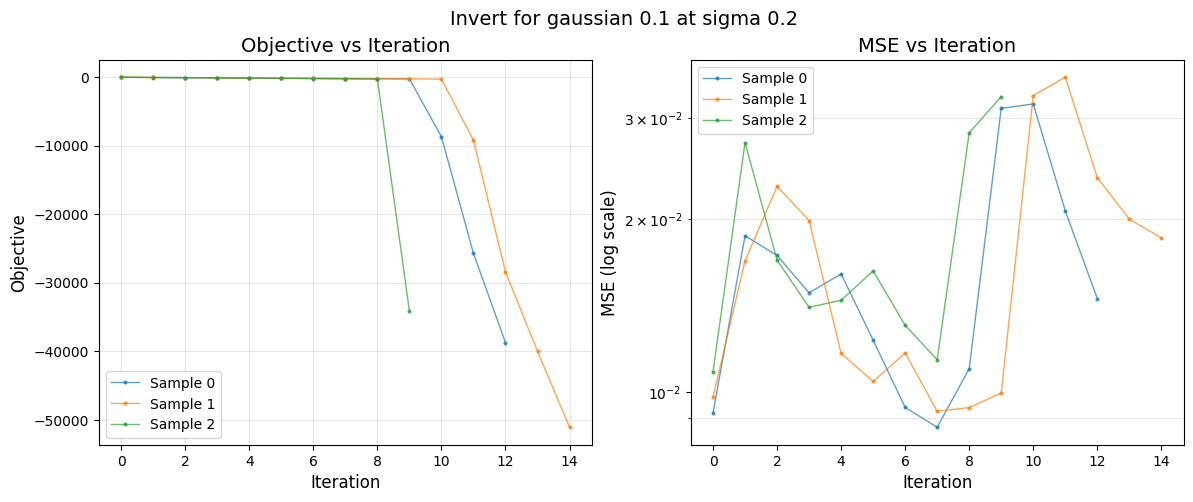

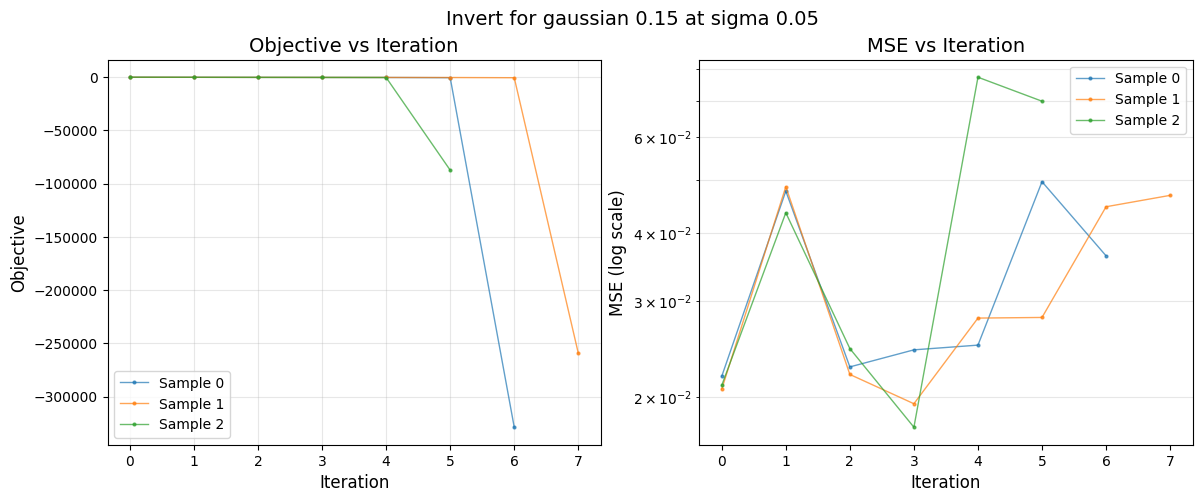

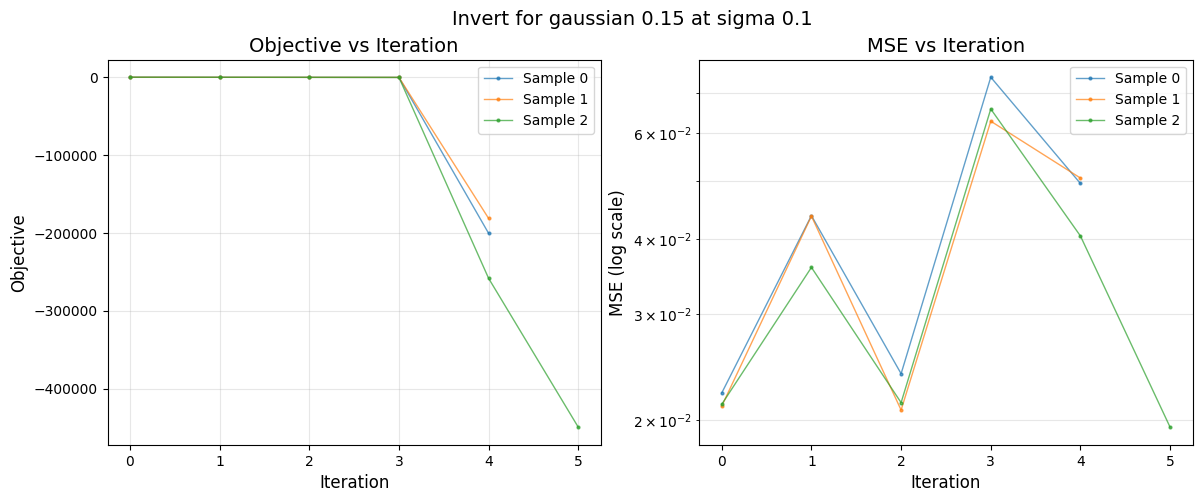

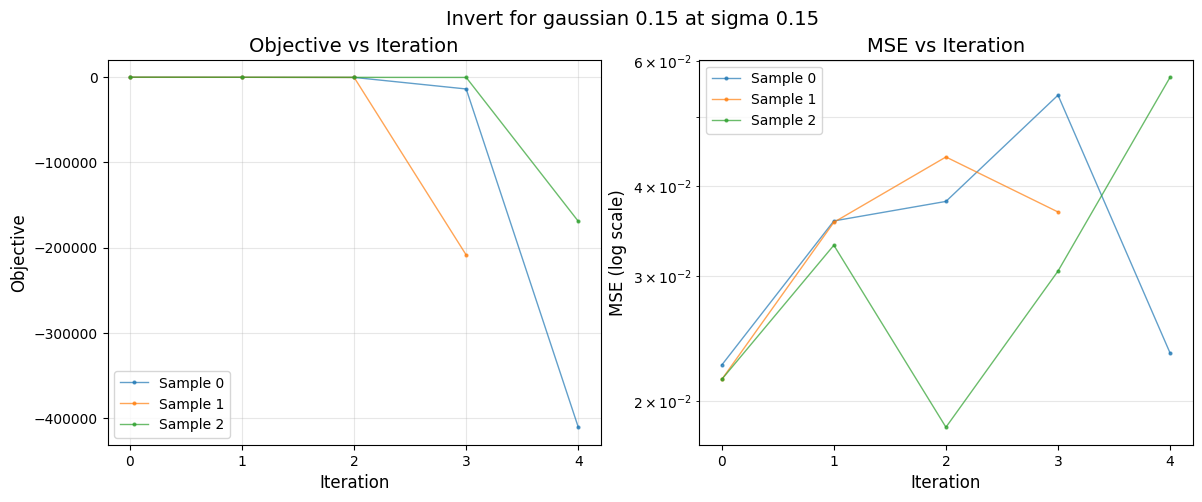

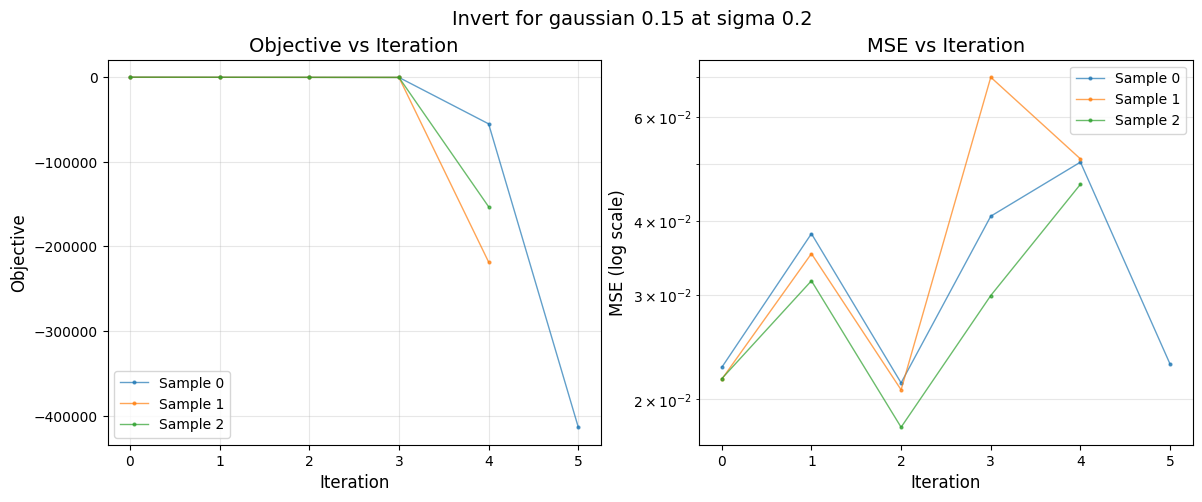

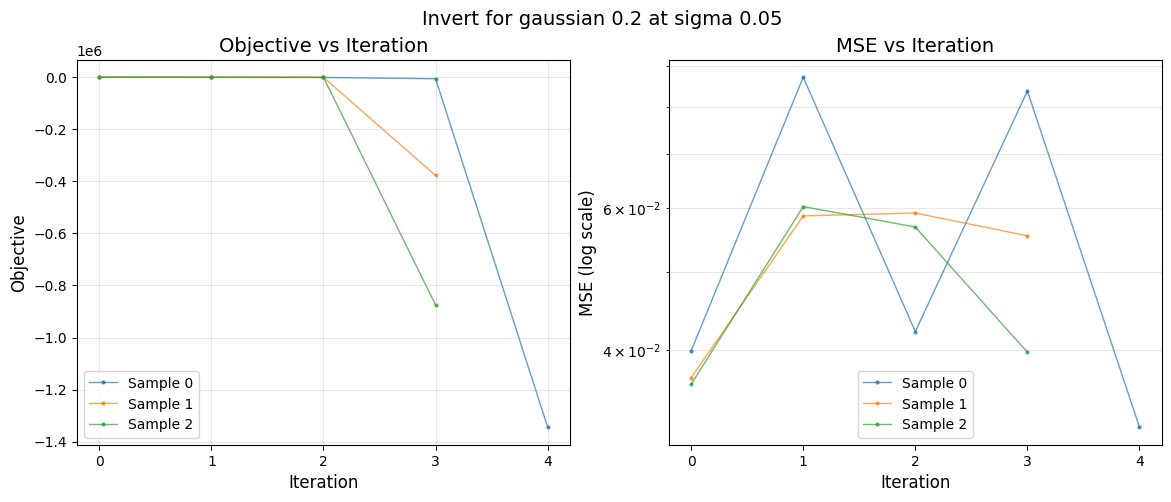

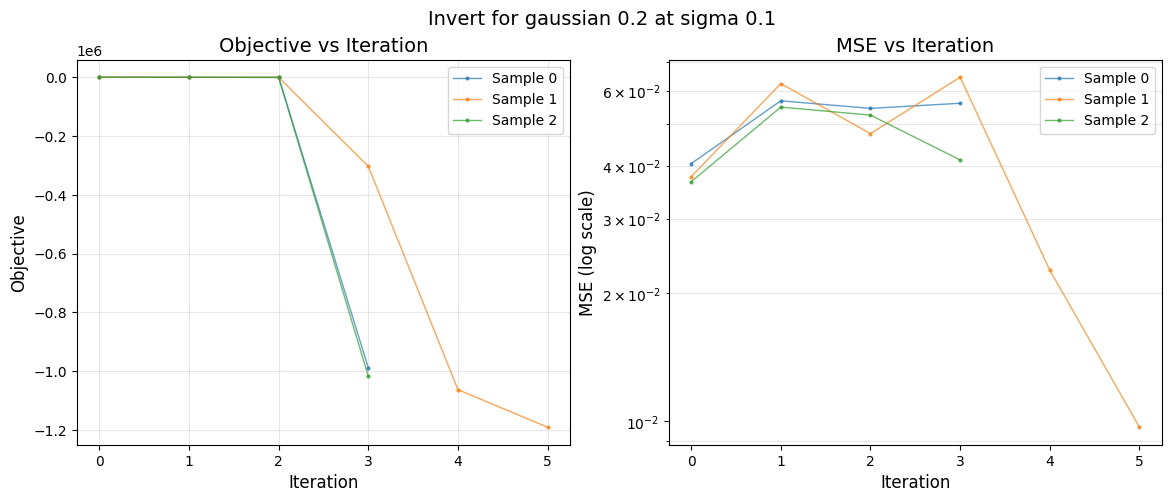

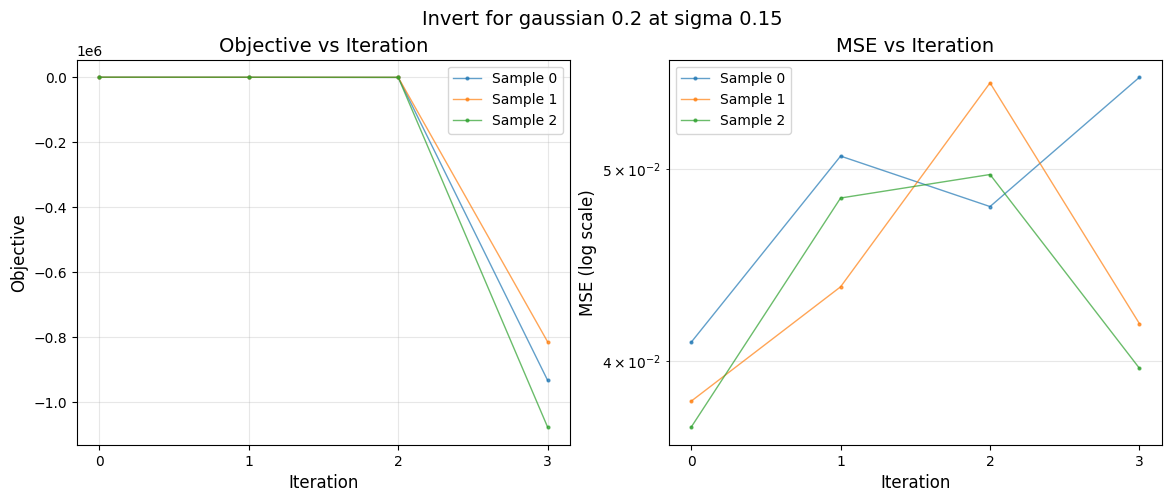

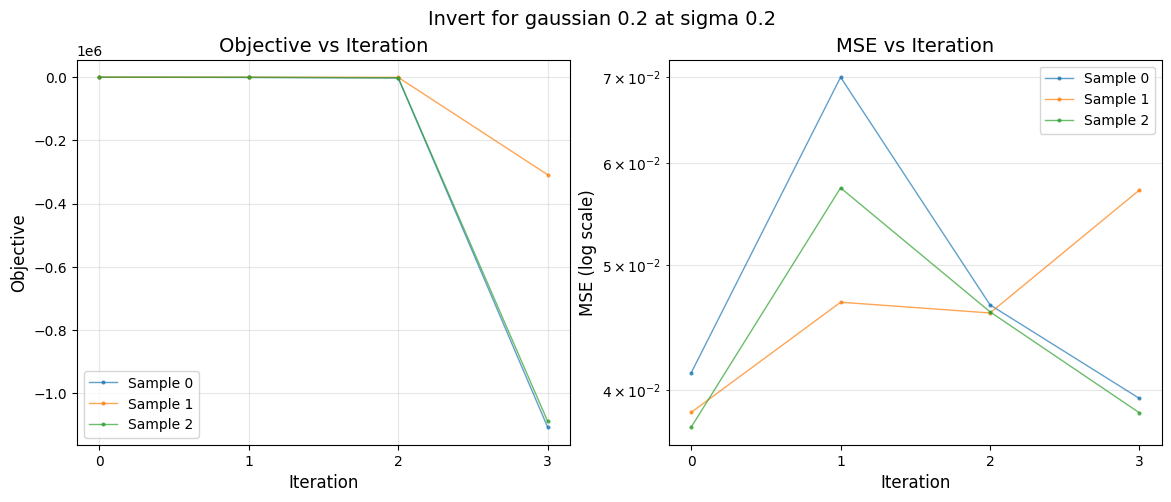

In [27]:
for g in [0.05, 0.1, 0.15, 0.2]:
    for sigma in [0.05, 0.10, 0.15, 0.20]:
        csv_path = f'../savings/lpn_cond_mrs_h_64_k_33_n_(0.05_0.2)/prior/mse_{g}_{sigma:.2f}.csv'
        df = pd.read_csv(csv_path)

        plot_invert(df, g, sigma, n_sample=3)

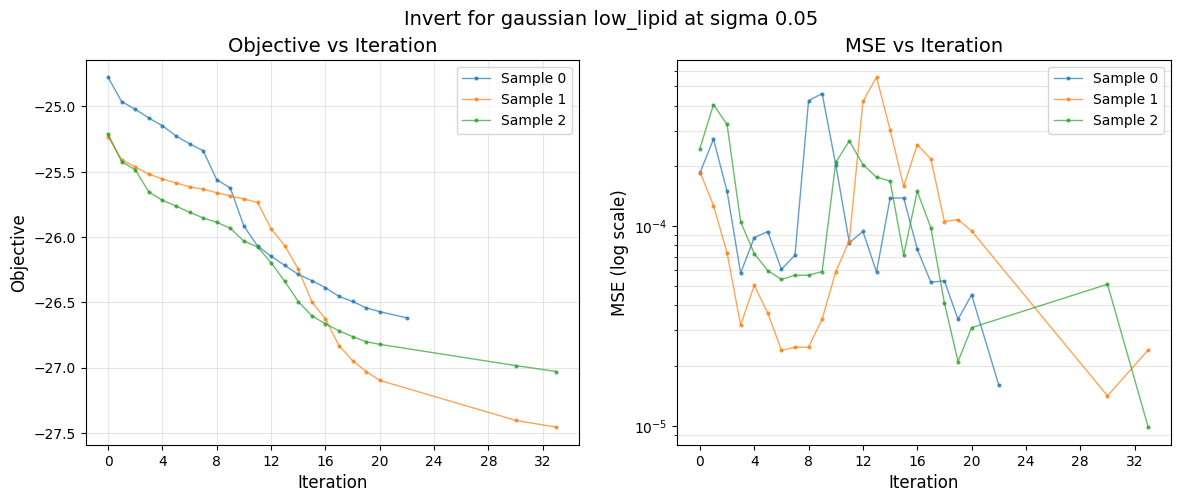

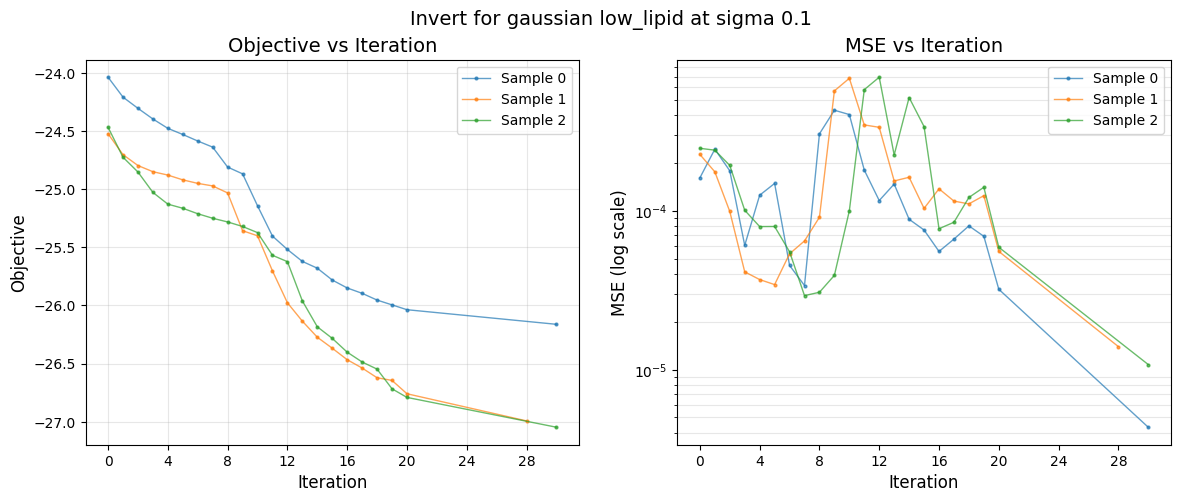

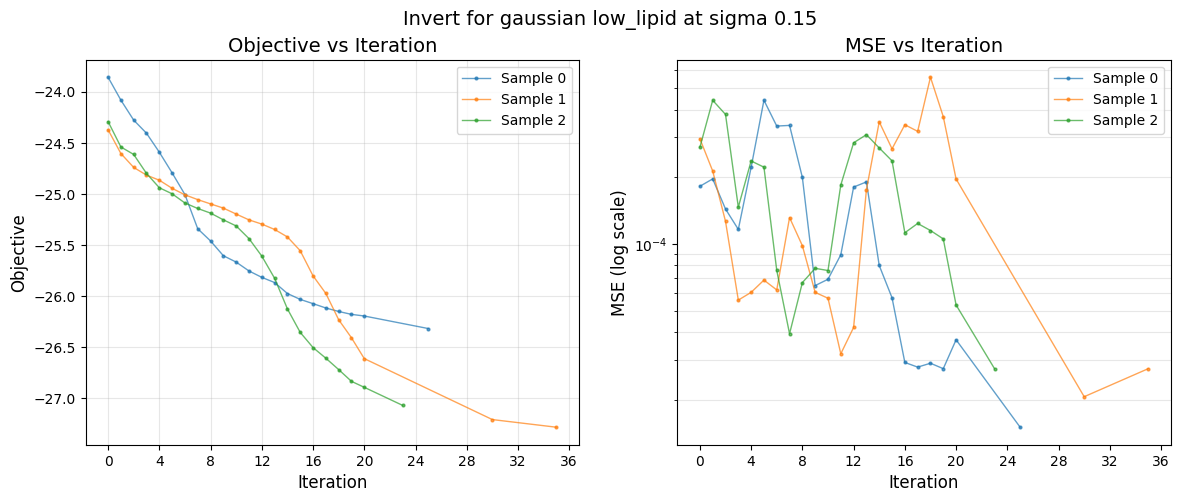

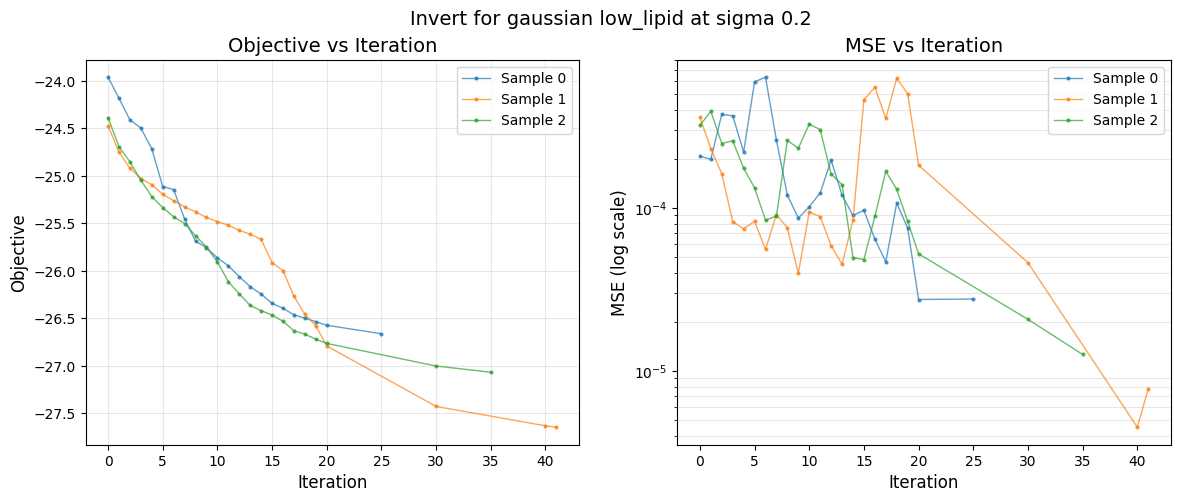

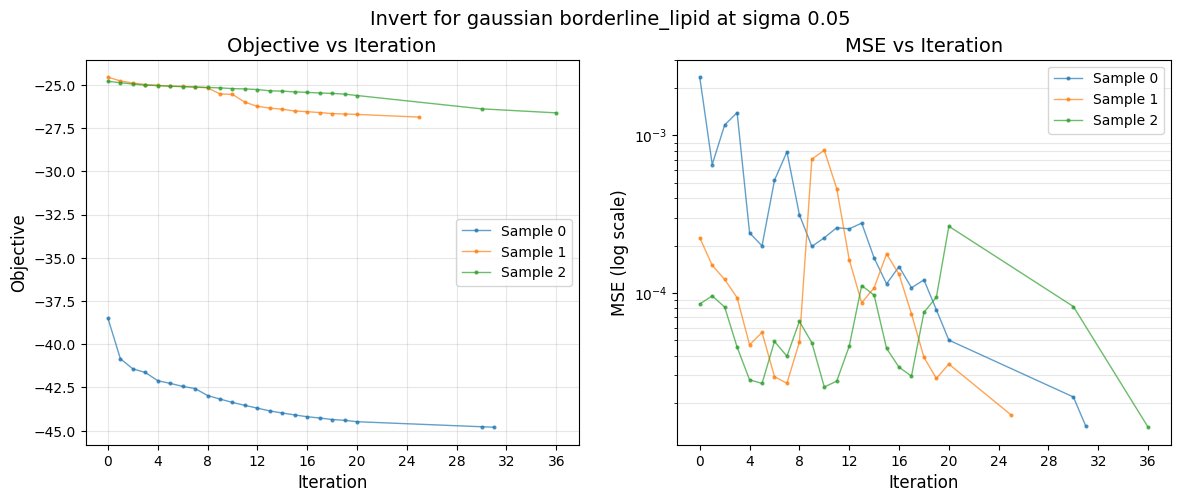

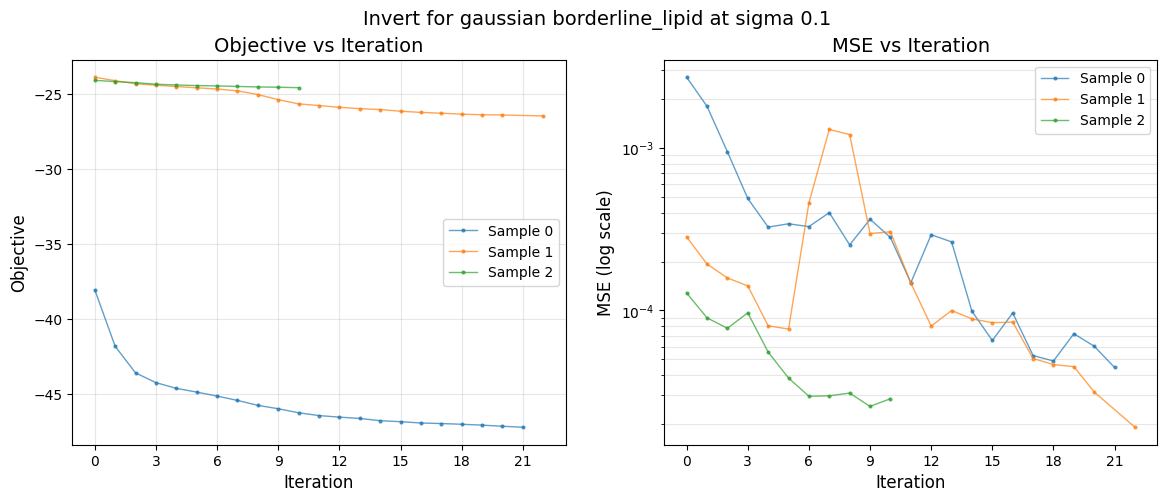

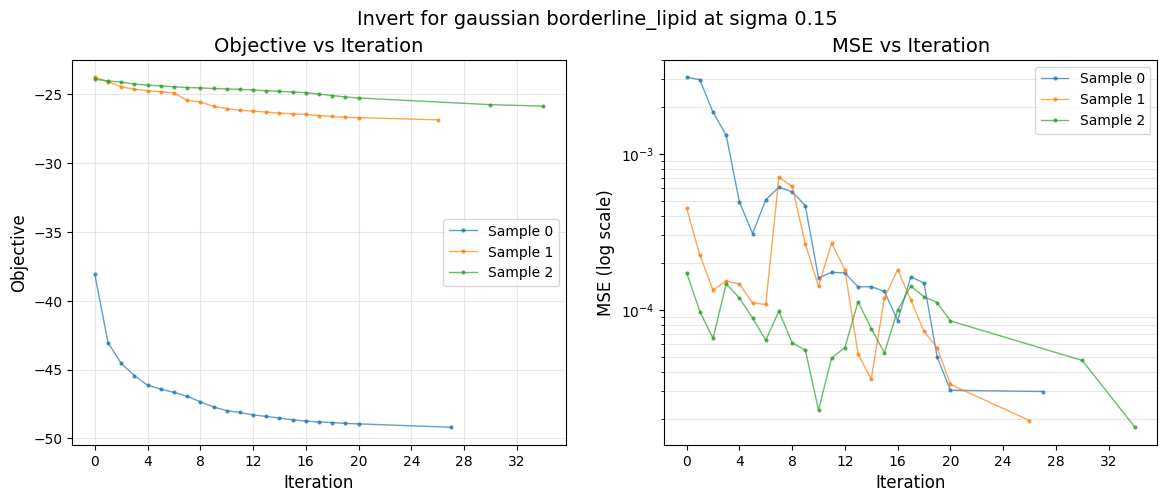

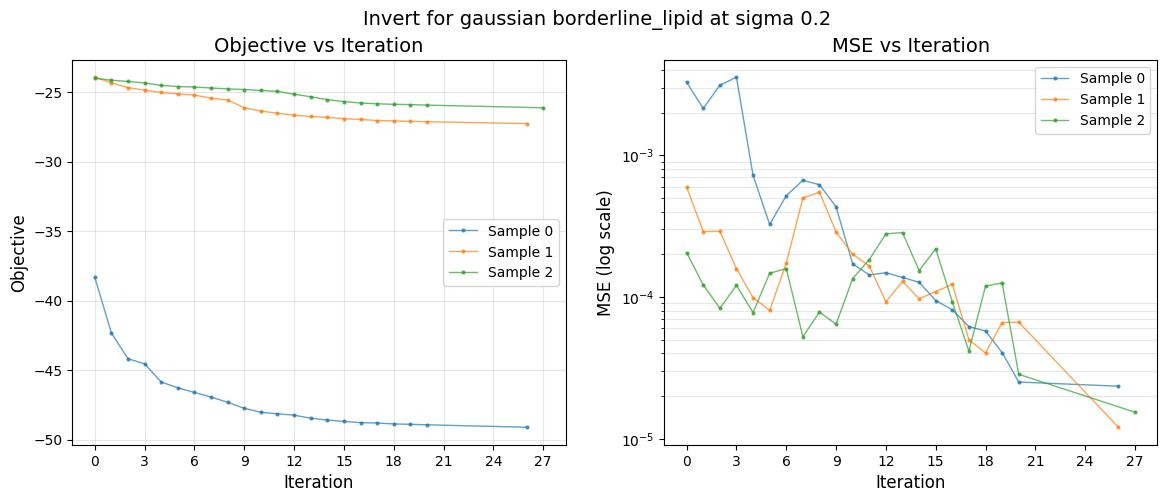

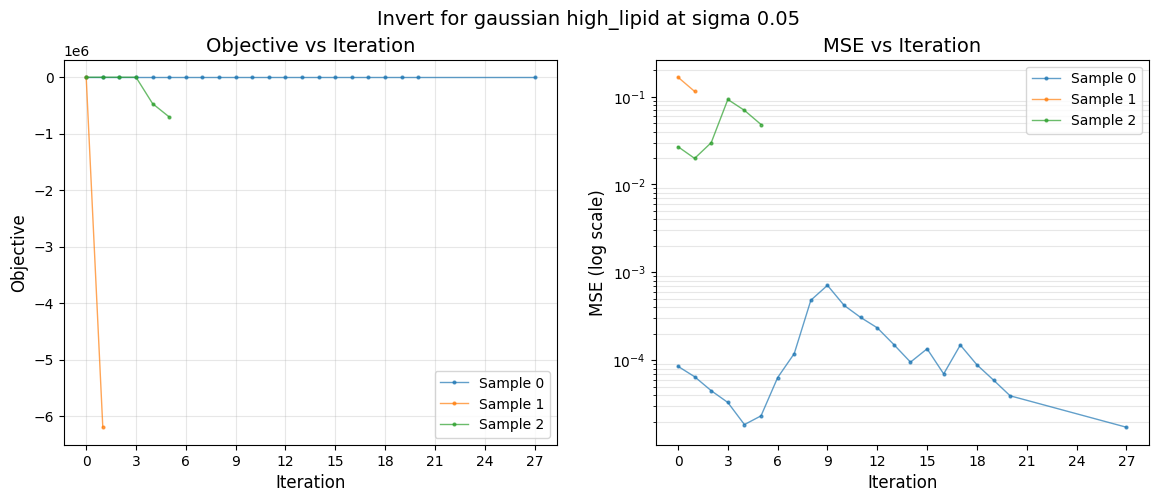

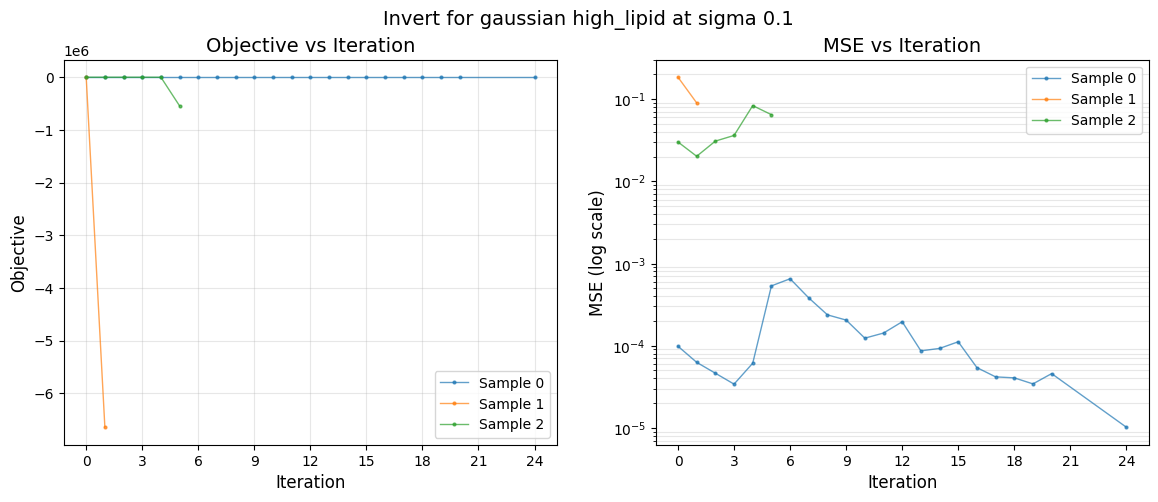

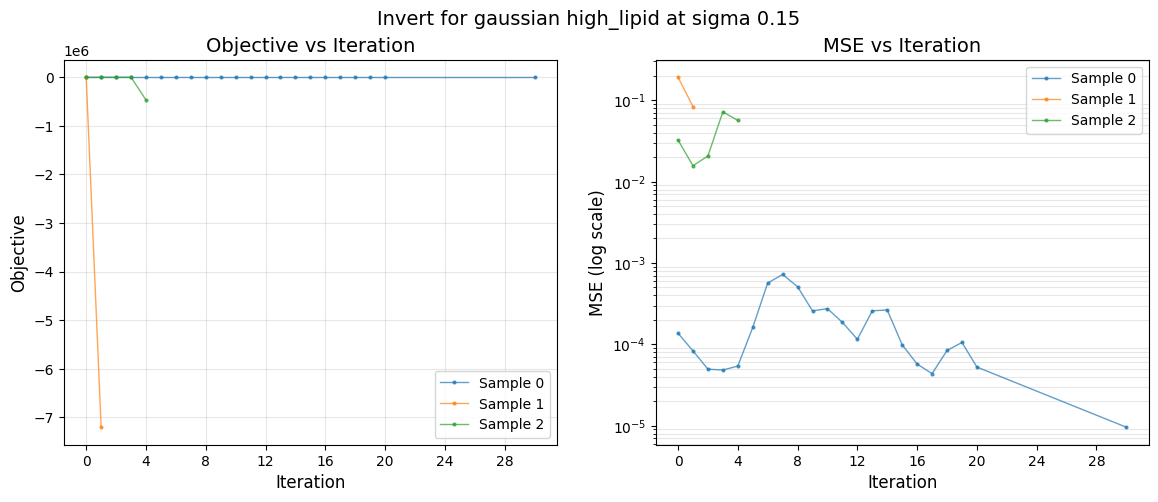

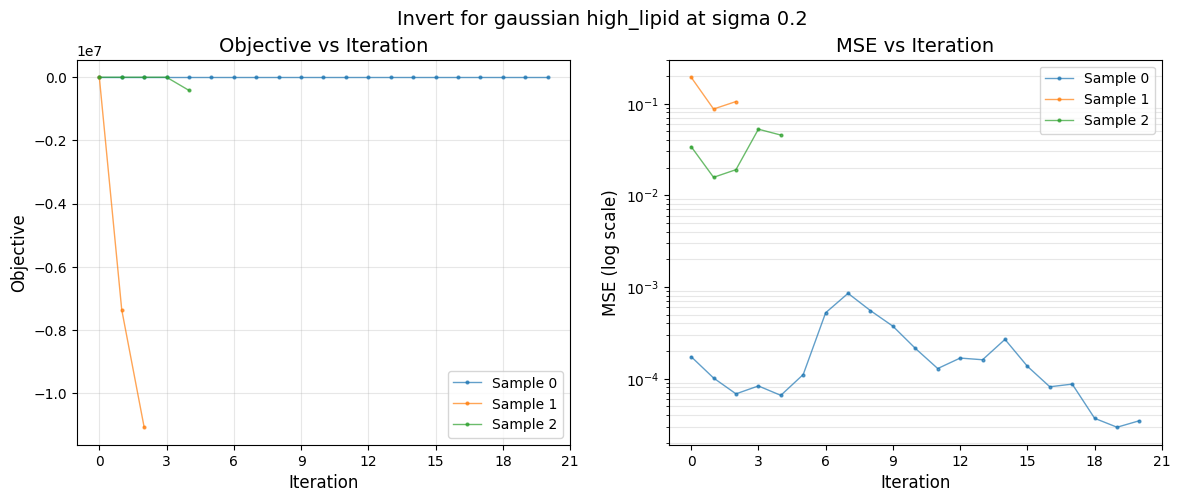

In [28]:
for g in ['low_lipid', 'borderline_lipid', 'high_lipid']:
    for sigma in [0.05, 0.10, 0.15, 0.20]:
        csv_path = f'../savings/lpn_cond_mrs_h_64_k_33_n_(0.05_0.2)/prior/mse_{g}_{sigma:.2f}.csv'
        df = pd.read_csv(csv_path)

        plot_invert(df, g, sigma, n_sample=3)